In [ ]:
import pandas as pd
data = pd.read_csv('data2.csv')
print(data)

dataframe = pd.DataFrame(data)
print(dataframe)

dataframe.describe()

        t      y
0   0.644  1.938
1   0.647  1.944
2   0.655  1.927
3   0.647  2.027
4   0.654  1.913
..    ...    ...
95  0.646  2.009
96  0.643  1.953
97  0.651  1.925
98  0.653  1.909
99  0.655  2.004

[100 rows x 2 columns]
        t      y
0   0.644  1.938
1   0.647  1.944
2   0.655  1.927
3   0.647  2.027
4   0.654  1.913
..    ...    ...
95  0.646  2.009
96  0.643  1.953
97  0.651  1.925
98  0.653  1.909
99  0.655  2.004

[100 rows x 2 columns]


,t,y
count,100.000000,100.000000
mean,0.650060,1.990760
std,0.005988,0.057586
min,0.640000,1.902000
25%,0.644750,1.938000
50%,0.650500,1.988000
75%,0.655000,2.041250
max,0.660000,2.094000


In [15]:
y=dataframe['y'].values   
t=dataframe['t'].values

g=2*y/t**2
print(g)

new_data_frame = pd.DataFrame({'t': t, 'y': y, 'g': g})
print(new_data_frame)

#save the new data frame to a new csv file
new_data_frame.to_csv('g-values.csv', index=False)

[ 9.34570426  9.28790351  8.98315949  9.68445494  8.94518793 10.01057831
  9.37652904  9.11678747  9.11851991  9.75761225  9.09504108  9.60297357
  9.9533197   9.04483503  9.63863333 10.12695312  9.56587611  9.56942301
  9.96495336  9.7340886   9.35550683  9.97589636  9.67489949  9.41230487
  9.29268124  9.57391434  9.41833213  9.46509103 10.05708792  9.49382484
  9.292097   10.08336487  9.74349806  9.88769531  9.53552539  8.84978304
  9.12546075  9.12304867 10.09538041  9.53464023  9.40865742 10.1171875
  9.04022971  8.99544582  9.53989189  9.52587245  9.06172243  9.55930164
  9.68809074  9.32907138  9.27684867  9.03668639  9.81829405  9.01950944
  9.36995857  9.61381783  9.08571762  9.85277813  8.78594987  9.17898074
  9.3547917   8.73737374  9.69516988  9.63504494  9.7179878   9.27182481
  9.63298795  8.86909766  9.34092283  9.68923267  9.45821855  8.8852631
  9.49112426  8.84978304  9.10835937  9.30230315  9.50163192  9.2019044
  9.69010262  9.70232759  9.24463674  9.37794545  9.59

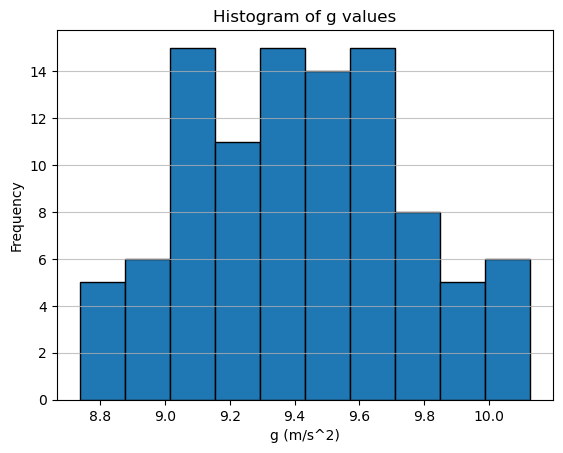

In [16]:
# plot histogram of g values
import matplotlib.pyplot as plt
plt.hist(g, bins=10, edgecolor='black')
plt.title('Histogram of g values')
plt.xlabel('g (m/s^2)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

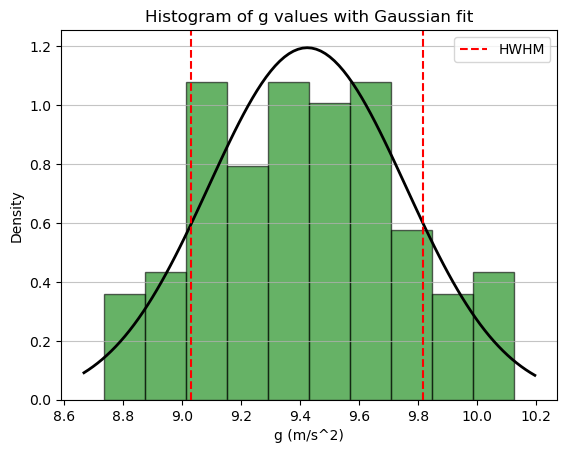

Mean (mu): 9.424784424417455
Standard Deviation (std): 0.33394485142720703


In [34]:
#fit a guassian to the g values and plot the histogram with the fit, then print the mean and standard deviation of the fit. Also plot the HWHM on the histogram.
import numpy as np
from scipy.stats import norm
# Fit a Gaussian to the g values
mu, std = norm.fit(g)
# Plot the histogram of g values
plt.hist(g, bins=10, density=True, alpha=0.6, color='g', edgecolor='black')
# Plot the PDF of the fitted Gaussian
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Histogram of g values with Gaussian fit')
plt.xlabel('g (m/s^2)')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
# Plot the HWHM
hwhm = std * np.sqrt(2 * np.log(2))
plt.axvline(mu - hwhm, color='r', linestyle='--', label='HWHM')
plt.axvline(mu + hwhm, color='r', linestyle='--')
plt.legend()
plt.show()
print(f'Mean (mu): {mu}')
print(f'Standard Deviation (std): {std}')   


Estimated g from Monte Carlo: 9.416923464703093


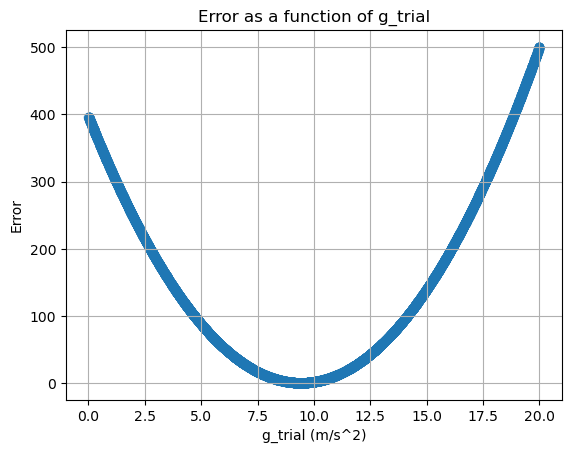

In [50]:
#Using Monte Carlo method to estimate g from the model g=2*y/t^2

# model is g=2y/t^2 + error 

# y and t come from data. they have noise. 

#Method: Random Monte carlo search 

#1- repeatedly draw random trials models (gtrial)  from [0 to 20]. 

# 2 for each gtrial, calculate the predicted y values using the model and the t values from the data.
#3- calculate predicted error for each gtrial as the sum of squared differences between the predicted y values and the actual y values from the data.

#4- if the trial has a lower rror than the best solution found so far, accept it as a the new best model. 


gmin = 0
gmax = 20
num_trials = 10000
best_g = None
best_error = float('inf')

for i in range(num_trials):
    g_trial = np.random.uniform(gmin, gmax)
    y_predicted = 0.5 * g_trial * t**2
    error = np.sum((y - y_predicted)**2)

    if error < best_error:
        best_error = error
        best_g = g_trial

print(f'Estimated g from Monte Carlo: {best_g}')

#plot error as a function of g_trial
g_trials = np.random.uniform(gmin, gmax, num_trials)
errors = []
for g_trial in g_trials:
    y_predicted = 0.5 * g_trial * t**2
    error = np.sum((y - y_predicted)**2)
    errors.append(error)    
plt.scatter(g_trials, errors, alpha=0.5)
plt.title('Error as a function of g_trial')
plt.xlabel('g_trial (m/s^2)')
plt.ylabel('Error')
plt.grid()
plt.show()


